# 5-Wege-Benchmark: Decoder-Only vs. Encoder-Decoder Modelle

1. **Decoder-Only Basismodell (`Qwen2.5-1.5B`):** Unberührte **Few-Shot Baseline** mit In-Context-Learning.

2. **Decoder-Only SFT Modell:** Supervised Fine-Tuned LoRA Adapter auf Qwen.

3. **Decoder-Only DPO Modell:** Preference-Aligned LoRA Adapter auf Qwen.

4. **Encoder-Decoder SFT Modell:** Feinabgestimmtes `mBART-50`.

5. **Encoder-Decoder DPO Modell:** Direct Preference Optimized `mBART-50`.


In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

def find_repo_root():
    p = os.path.abspath(os.getcwd())
    while p != os.path.dirname(p):
        if os.path.exists(os.path.join(p, 'data')) and os.path.exists(os.path.join(p, 'results')):
            return p
        p = os.path.dirname(p)
    return os.path.abspath(os.path.expanduser('~/Documents/Master Thesis'))

REPO_ROOT = find_repo_root()
os.chdir(REPO_ROOT)
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

print('Arbeitsverzeichnis:', os.getcwd())


Arbeitsverzeichnis: /Users/fietescheel/Documents/Master Thesis


## 1. 5-Wege-Benchmark-Ergebnisse laden


In [2]:
CSV_PATH = os.path.join(REPO_ROOT, 'results/evaluation/benchmark_5way_decoder_vs_encoder_decoder.csv')
if not os.path.exists(CSV_PATH):
    CSV_PATH = 'results/evaluation/benchmark_5way_decoder_vs_encoder_decoder.csv'

df_eval = pd.read_csv(CSV_PATH)
print(f'5-Wege-Benchmark erfolgreich geladen: {len(df_eval)} Artikel aus {CSV_PATH}')
display(df_eval.head())


5-Wege-Benchmark erfolgreich geladen: 37 Artikel aus /Users/fietescheel/Documents/Master Thesis/results/evaluation/benchmark_5way_decoder_vs_encoder_decoder.csv


,id,source_text,target_text,gen_dec_fs,r_style_dec_fs,r_sem_as_dec_fs,composite_dec_fs,lix_dec_fs,flesch_dec_fs,wiener_dec_fs,...,rouge_l_enc_sft,gen_enc_dpo,r_style_enc_dpo,r_sem_as_enc_dpo,composite_enc_dpo,lix_enc_dpo,flesch_enc_dpo,wiener_enc_dpo,bleu_enc_dpo,rouge_l_enc_dpo
0,0,"Kiel, 15.10.2020. Arbeit zweiter oder dritter ...",Positionspapier: Bildung und Teilhabe am Arbei...,In Kiel am 15. Oktober 2020. Was ist mit der A...,0.616682,0.802909,0.709795,33.035714,57.592857,6.126771,...,0.136017,Was ist die Arbeit in einer Werkstatt? In der ...,0.988664,0.823818,0.906241,36.250000,57.486250,6.812700,0.016816,0.174953
1,1,„Kieler Sicherheitskonzept Sexualstraftäter“ (...,Infos zum Kieler Sicherheitskonzept Sexualstra...,Der Zug zwischen Hamburg und Hannover bleibt a...,0.466360,0.659436,0.562898,46.342105,62.736842,7.946205,...,0.196139,Was ist das Kieler-Sicherheits-Konzept? Das Ki...,0.926629,0.813814,0.870221,42.225520,45.662000,8.314189,0.039120,0.181402
2,2,"Zielgruppe: Menschen, die auf der Suche nach W...",Fischbeker Reethen. In Hamburg entsteht ein ne...,"Das Ziel ist es, viele Menschen in einem neuen...",0.173351,0.799006,0.486178,42.386340,40.691641,10.380770,...,0.124885,Was ist das neue Quartier? Das ist ein großes ...,0.958194,0.922393,0.940293,35.408178,51.275875,7.312088,0.066515,0.224599
3,3,Satzung der Stadt Pinneberg für den „Beirat fü...,Satzung von der Stadt Pinneberg für den Beirat...,Die Stadt Pinneberg hat einen Beirat für Mensc...,0.757110,0.922678,0.839894,47.363636,44.909091,9.924900,...,0.182260,Was ist ein Beirat für Menschen mit Behinderun...,0.979209,0.873136,0.926172,41.943061,43.897408,9.011328,0.035565,0.177544
4,4,"Ministerium für Soziales, Jugend, Familie, Sen...",22. November 2024. Es gibt ein neues Gesetz fü...,Das neue KiTa-Gesetz geht in Kraft am 1. Janua...,0.080687,0.924317,0.502502,47.871102,27.899168,11.332383,...,0.154706,Was ist ein KiTa-Gesetz? Das KiTa ist eine Ein...,0.975300,0.910480,0.942890,33.627065,50.737431,7.093691,0.064091,0.215069


## 2. Wissenschaftliche 5-Wege-Gesamtvergleichstabelle


In [3]:
summary_csv = os.path.join(REPO_ROOT, 'results/evaluation/master_benchmark_summary.csv')

if os.path.exists(summary_csv):
    df_master_table = pd.read_csv(summary_csv)
    print('=' * 105)
    print('  WISSENSCHAFTLICHE GESAMT-VERGLEICHSTABELLE (5-WEGE-BENCHMARK, N=37)')
    print('=' * 105)
    display(df_master_table)
else:
    def format_mean_std(values):
        return f'{np.mean(values):.4f} ± {np.std(values):.4f}'

    models_config = [
        ('1. Few-Shot Baseline (Qwen-1.5B)', 'r_style_dec_fs', 'r_sem_as_dec_fs', 'composite_dec_fs', 'lix_dec_fs', 'flesch_dec_fs'),
        ('2. Decoder-Only SFT (Qwen-1.5B)', 'r_style_dec_sft', 'r_sem_as_dec_sft', 'composite_dec_sft', 'lix_dec_sft', 'flesch_dec_sft'),
        ('3. Decoder-Only DPO (Qwen-1.5B)', 'r_style_dec_dpo', 'r_sem_as_dec_dpo', 'composite_dec_dpo', 'lix_dec_dpo', 'flesch_dec_dpo'),
        ('4. Encoder-Decoder SFT (mBART-50)', 'r_style_enc_sft', 'r_sem_as_enc_sft', 'composite_enc_sft', 'lix_enc_sft', 'flesch_enc_sft'),
        ('5. Encoder-Decoder DPO (mBART-50)', 'r_style_enc_dpo', 'r_sem_as_enc_dpo', 'composite_enc_dpo', 'lix_enc_dpo', 'flesch_enc_dpo'),
    ]

    rows = []
    for name, c_st, c_sm, c_tot, c_lix, c_fl in models_config:
        rows.append({
            'Modell / Paradigma': name,
            'Simplicity (R_style)': format_mean_std(df_eval[c_st]),
            'SBERT-Quelltreue (R_sem)': format_mean_std(df_eval[c_sm]),
            'Composite Total Reward': format_mean_std(df_eval[c_tot]),
            'LIX Index (↓)': format_mean_std(df_eval[c_lix]),
            'Flesch DE (↑)': format_mean_std(df_eval[c_fl]),
        })

    df_master_table = pd.DataFrame(rows)
    print('=' * 105)
    print('  WISSENSCHAFTLICHE GESAMT-VERGLEICHSTABELLE (5-WEGE-BENCHMARK, N=37)')
    print('=' * 105)
    display(df_master_table)


  WISSENSCHAFTLICHE GESAMT-VERGLEICHSTABELLE (5-WEGE-BENCHMARK, N=37)


,Modell / Paradigma,Simplicity (R_style),SBERT-Quelltreue (R_sem),Composite Total Reward,LIX Index (↓),Flesch DE (↑),Wiener Sachtext (↓),BLEU (↑),ROUGE-L (↑)
0,1. Few-Shot Baseline (Qwen-1.5B),0.4315 ± 0.2839,0.7615 ± 0.1573,0.5965 ± 0.1623,48.4865 ± 34.1071,39.4201 ± 33.2035,9.6663 ± 5.6674,0.0029 ± 0.0064,0.0824 ± 0.0645
1,2. Decoder-Only SFT (Qwen-1.5B),0.8923 ± 0.1648,0.7810 ± 0.0831,0.8366 ± 0.0762,35.5172 ± 9.3377,44.1219 ± 26.5720,7.0374 ± 3.2527,0.0261 ± 0.0543,0.1601 ± 0.0846
2,3. Decoder-Only DPO (Qwen-1.5B),0.8279 ± 0.2360,0.7698 ± 0.0699,0.7989 ± 0.1106,36.3851 ± 21.0632,45.1272 ± 45.9648,7.0915 ± 4.3324,0.0186 ± 0.0485,0.1209 ± 0.0868
3,4. Encoder-Decoder SFT (mBART-50),0.7207 ± 0.1990,0.9001 ± 0.0329,0.8104 ± 0.0955,39.5352 ± 6.0766,43.3588 ± 10.5077,8.5409 ± 1.6125,0.0358 ± 0.0397,0.1691 ± 0.0546
4,5. Encoder-Decoder DPO (mBART-50),0.9578 ± 0.0361,0.8792 ± 0.0394,0.9185 ± 0.0283,34.8735 ± 4.3397,50.8625 ± 6.7034,7.1199 ± 1.1209,0.0414 ± 0.0218,0.1867 ± 0.0341


## 3. Publikationsreife Visualisierungen (Boxplots über alle 5 Modellvarianten)


/var/folders/b4/clxxd_yn5655dz4hq58pqznh0000gn/T/ipykernel_22118/3847596004.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], data=df_plot, x="Modell", y="Simplicity (R_style)", palette=palette)
/var/folders/b4/clxxd_yn5655dz4hq58pqznh0000gn/T/ipykernel_22118/3847596004.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1], data=df_plot, x="Modell", y="SBERT-Treue (R_sem)", palette=palette)
/var/folders/b4/clxxd_yn5655dz4hq58pqznh0000gn/T/ipykernel_22118/3847596004.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot

Vergleichs-Plot gespeichert unter: results/plots/benchmark_5way_decoder_vs_encoder_decoder.png


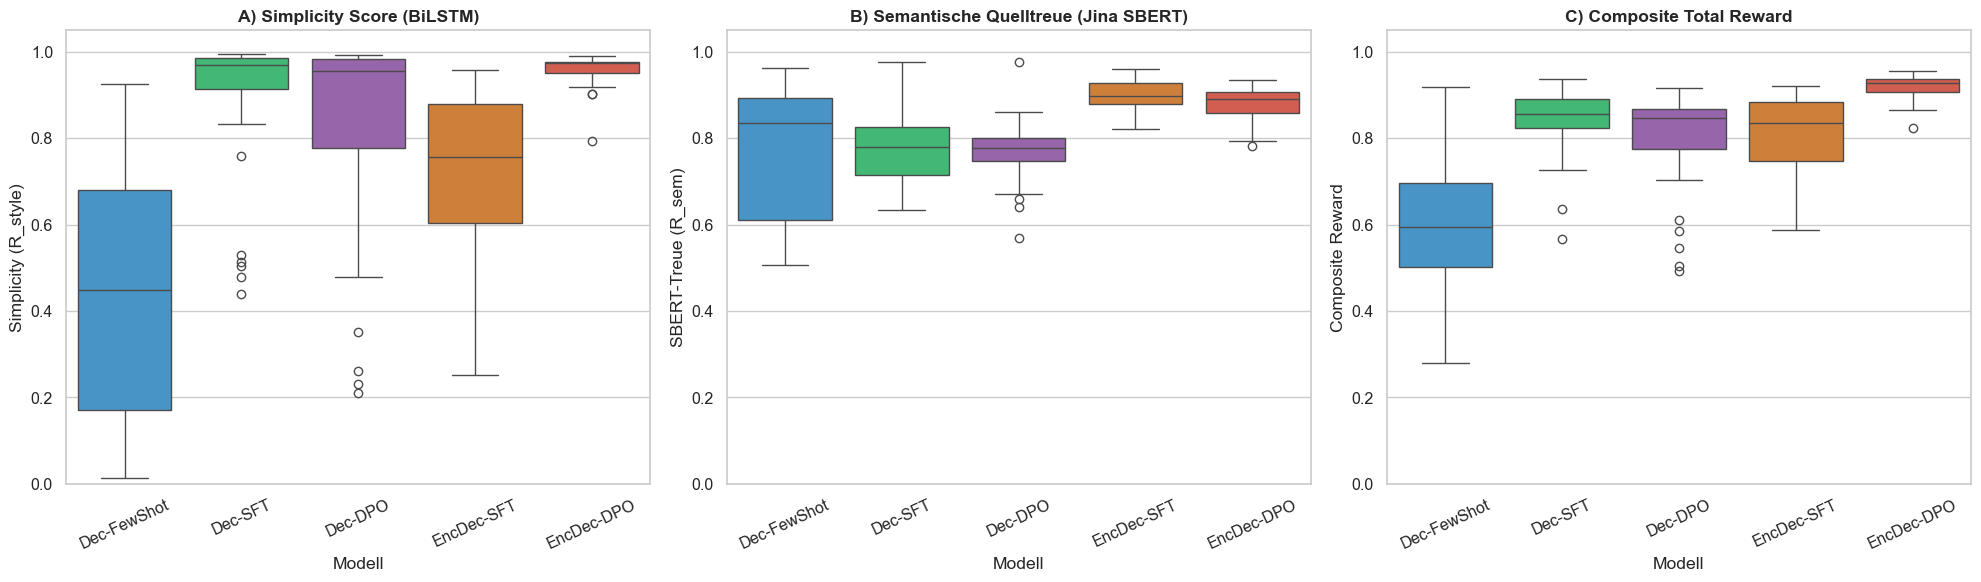

In [4]:
sns.set_theme(style="whitegrid", font_scale=1.05)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

plot_data = []
short_names = [
    ("Dec-FewShot", "r_style_dec_fs", "r_sem_as_dec_fs", "composite_dec_fs"),
    ("Dec-SFT", "r_style_dec_sft", "r_sem_as_dec_sft", "composite_dec_sft"),
    ("Dec-DPO", "r_style_dec_dpo", "r_sem_as_dec_dpo", "composite_dec_dpo"),
    ("EncDec-SFT", "r_style_enc_sft", "r_sem_as_enc_sft", "composite_enc_sft"),
    ("EncDec-DPO", "r_style_enc_dpo", "r_sem_as_enc_dpo", "composite_enc_dpo"),
]

for model_name, col_style, col_sem, col_tot in short_names:
    for _, row in df_eval.iterrows():
        plot_data.append({
            "Modell": model_name,
            "Simplicity (R_style)": row[col_style],
            "SBERT-Treue (R_sem)": row[col_sem],
            "Composite Reward": row[col_tot],
        })

df_plot = pd.DataFrame(plot_data)
palette = ["#3498db", "#2ecc71", "#9b59b6", "#e67e22", "#e74c3c"]

# Simplicity
sns.boxplot(ax=axes[0], data=df_plot, x="Modell", y="Simplicity (R_style)", palette=palette)
axes[0].set_title("A) Simplicity Score (BiLSTM)", fontweight="bold")
axes[0].set_ylim(0, 1.05)
axes[0].tick_params(axis='x', rotation=25)

sns.boxplot(ax=axes[1], data=df_plot, x="Modell", y="SBERT-Treue (R_sem)", palette=palette)
axes[1].set_title("B) Semantische Quelltreue (Jina SBERT)", fontweight="bold")
axes[1].set_ylim(0, 1.05)
axes[1].tick_params(axis='x', rotation=25)

# Composite Reward
sns.boxplot(ax=axes[2], data=df_plot, x="Modell", y="Composite Reward", palette=palette)
axes[2].set_title("C) Composite Total Reward", fontweight="bold")
axes[2].set_ylim(0, 1.05)
axes[2].tick_params(axis='x', rotation=25)

plt.tight_layout()
plot_path = "results/plots/benchmark_5way_decoder_vs_encoder_decoder.png"
plt.savefig(plot_path, dpi=300)
print(f"Vergleichs-Plot gespeichert unter: {plot_path}")
plt.show()

## 4. Qualitatives Side-by-Side Stichproben-Audit (Beispielartikel)


In [5]:
sep = '=' * 105
print(sep)
print('  QUALITATIVE STICHPROBEN: SIDE-BY-SIDE VERGLEICH ALLER 5 MODELLE')
print(sep)

def clean_snippet(text, max_len=300):
    t = str(text or '').strip()
    if t.endswith('...'):
        t = t[:-3].strip()
    if len(t) > max_len:
        return t[:max_len].strip() + ' [...]'
    return t

as_col = 'source_text' if 'source_text' in df_eval.columns else 'as_text'
ref_col = 'target_text' if 'target_text' in df_eval.columns else 'ls_ref_text'
t_fs_col = 'gen_dec_fs' if 'gen_dec_fs' in df_eval.columns else 'translation_dec_fs'
t_sft_dec_col = 'gen_dec_sft' if 'gen_dec_sft' in df_eval.columns else 'translation_dec_sft'
t_dpo_dec_col = 'gen_dec_dpo' if 'gen_dec_dpo' in df_eval.columns else 'translation_dec_dpo'
t_sft_enc_col = 'gen_enc_sft' if 'gen_enc_sft' in df_eval.columns else 'translation_enc_sft'
t_dpo_enc_col = 'gen_enc_dpo' if 'gen_enc_dpo' in df_eval.columns else 'translation_enc_dpo'

for idx in range(min(5, len(df_eval))):
    row = df_eval.iloc[idx]
    title = row.get('title', row.get('id', f'Artikel {idx+1}'))

    print('')
    print(sep)
    print(f'[ARTIKEL {idx+1}]: {title}')
    print(sep)
    print('[1. AS-QUELLE]:')
    print(clean_snippet(row[as_col]))
    print('')
    print('[2. LEBENSHILFE GOLD REFERENZ]:')
    print(clean_snippet(row[ref_col]))
    print('')
    print(f'[3. FEW-SHOT BASELINE (Qwen-1.5B)] (Style: {row["r_style_dec_fs"]:.3f} | Sem: {row["r_sem_as_dec_fs"]:.3f} | Comp: {row["composite_dec_fs"]:.3f}):')
    print(clean_snippet(row[t_fs_col]))
    print('')
    print(f'[4. DECODER-ONLY SFT (Qwen-1.5B)] (Style: {row["r_style_dec_sft"]:.3f} | Sem: {row["r_sem_as_dec_sft"]:.3f} | Comp: {row["composite_dec_sft"]:.3f}):')
    print(clean_snippet(row[t_sft_dec_col]))
    print('')
    print(f'[5. DECODER-ONLY DPO (Qwen-1.5B)] (Style: {row["r_style_dec_dpo"]:.3f} | Sem: {row["r_sem_as_dec_dpo"]:.3f} | Comp: {row["composite_dec_dpo"]:.3f}):')
    print(clean_snippet(row[t_dpo_dec_col]))
    print('')
    print(f'[6. ENCODER-DECODER SFT (mBART-50)] (Style: {row["r_style_enc_sft"]:.3f} | Sem: {row["r_sem_as_enc_sft"]:.3f} | Comp: {row["composite_enc_sft"]:.3f}):')
    print(clean_snippet(row[t_sft_enc_col]))
    print('')
    print(f'[7. ENCODER-DECODER DPO (mBART-50)] (Style: {row["r_style_enc_dpo"]:.3f} | Sem: {row["r_sem_as_enc_dpo"]:.3f} | Comp: {row["composite_enc_dpo"]:.3f}):')
    print(clean_snippet(row[t_dpo_enc_col]))
    print('-' * 105)


  QUALITATIVE STICHPROBEN: SIDE-BY-SIDE VERGLEICH ALLER 5 MODELLE

[ARTIKEL 1]: 0
[1. AS-QUELLE]:
Kiel, 15.10.2020. Arbeit zweiter oder dritter Klasse?? - Positionspapier Die Rede ist in diesemFall von der Entlohnung für Menschen, die in einer Werkstatt (WfbM) arbeiten. Wichtiges Detail: Es sind die Werkstätten selbst, die diese Veränderung dringend fordern. Der Lohn der Mitarbeiter*innen mit We [...]

[2. LEBENSHILFE GOLD REFERENZ]:
Positionspapier: Bildung und Teilhabe am Arbeitsleben für Alle in einem inklusiven Arbeitsmarkt. Positionspapier bedeutet: Mehrere Gruppen haben diesen Text geschrieben. Sie haben Ihre Meinung aufgeschrieben. Und sie haben Ihre Ideen aufgeschrieben. Diese Meinungen und Ideen heißen auch: Positionen [...]

[3. FEW-SHOT BASELINE (Qwen-1.5B)] (Style: 0.617 | Sem: 0.803 | Comp: 0.710):
In Kiel am 15. Oktober 2020. Was ist mit der Arbeit? - Ein Bericht über die Lohnentwicklung für Arbeiter in Werkstätten. Diese Arbeit macht große Probleme. Sie haben lange Zeit 